# Beyond the Job Title: Mapping Data Science Skills and the Closest Career Paths

**DSC680-T301 Applied Data Science (2271-1) — Project 1, Milestone 2**  
**Student:** Violetta Kalinicheva  
**Professor:** Xu Ashton  
**Data release:** O*NET 31.0 (August 2026)

### Analytical question

Which U.S. occupations are most similar to Data Scientists when occupations are compared on Essential Skills, Transferable Skills, Knowledge, and Work Activities—and which similarities remain when reasonable modeling choices change?



In [1]:
# SETUP: I first locate the project and tell the notebook where its input and output folders are.
# This lets the notebook run from either the project folder or the outputs folder without changing hard-coded paths.
from pathlib import Path
import os

# Locate this project whether the notebook is run from the repository root or outputs/.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = next(
    (p for p in candidates if (p / 'work/dsc680_project_screen/onet31/db_31_0_excel').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        'The audited O*NET 31.0 files were not found. Set DSC680_PROJECT_ROOT and '
        'ONET_DATA_DIR to the repository and extracted Excel directory before rerunning.'
    )
os.environ['DSC680_PROJECT_ROOT'] = str(project_root)
os.environ['ONET_DATA_DIR'] = str(project_root / 'work/dsc680_project_screen/onet31/db_31_0_excel')
os.environ['DSC680_RUN_DIR'] = str(project_root / 'work/dsc680_milestone2/notebook_run')
os.environ['MPLCONFIGDIR'] = str(project_root / 'work/dsc680_milestone2/.mplconfig')
os.environ['LOKY_MAX_CPU_COUNT'] = '8'
print('Project folder located successfully.')


Project folder located successfully.


## Shared imports and helper functions

In [2]:
# IMPORTS: I load the libraries used for cleaning, statistics, clustering, and visualization.
# I also define shared helper functions here so later steps do not repeat the same code.
"""DSC 680 Project 1, Milestone 2: reproducible O*NET analysis.

The pipeline deliberately separates intake/validation, cleaning, analysis, and
communication. It uses O*NET 31.0 Importance (IM) ratings for four domains and
treats O*NET's Recommend Suppress flag as a reliability warning rather than as
missing data in the raw source.
"""

from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import re
import sys
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import sklearn
from adjustText import adjust_text
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.stats import kendalltau, spearmanr
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import StandardScaler




## 1. Project setup

I am using the O*NET 31.0 release from August 2026 and O*NET-SOC code **15-2051.00** for Data Scientists. I use a random seed of 42 so my results can be repeated. I also verify the source file and create separate folders for my tables and figures.

In [3]:
# STEP 1: I set up the project before touching the data.
# I define the exact O*NET release, target occupation, random seed, folders, and colors here.
# Keeping these choices in one place makes my work easier to reproduce and prevents hidden changes.

PROJECT_ROOT = Path(os.environ.get("DSC680_PROJECT_ROOT", Path.cwd())).resolve()
DATA_DIR = Path(
    os.environ.get(
        "ONET_DATA_DIR",
        PROJECT_ROOT / "work/dsc680_project_screen/onet31/db_31_0_excel",
    )
)
ARCHIVE_PATH = DATA_DIR.parent / "db_31_0_excel.zip"
RUN_DIR = Path(os.environ.get("DSC680_RUN_DIR", PROJECT_ROOT / "work/dsc680_milestone2"))
RESULTS_DIR = RUN_DIR / "results"
FIGURES_DIR = RUN_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CODE = "15-2051.00"
TARGET_TITLE = "Data Scientists"
RANDOM_STATE = 42
TOP_K = 10
EXPECTED_ARCHIVE_SHA256 = "b8d9bc5bcf3ed90fcacf386ad40171a46d63cebb47acc250c2ae88a9f3448a23"

DOMAIN_FILES = {
    "Essential Skills": "Essential Skills.xlsx",
    "Transferable Skills": "Transferable Skills.xlsx",
    "Knowledge": "Knowledge.xlsx",
    "Work Activities": "Work Activities.xlsx",
}
DOMAIN_PREFIX = {
    "Essential Skills": "ES",
    "Transferable Skills": "TS",
    "Knowledge": "KN",
    "Work Activities": "WA",
}
EXPECTED_FEATURE_COUNTS = {
    "Essential Skills": 10,
    "Transferable Skills": 25,
    "Knowledge": 33,
    "Work Activities": 41,
}

COLORS = {
    "navy": "#1B365D",
    "blue": "#2F6B9A",
    "teal": "#159A9C",
    "gold": "#E6A700",
    "orange": "#D55E00",
    "purple": "#7A5195",
    "gray": "#667085",
    "light": "#E8EEF4",
    "red": "#B33A3A",
}

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
    }
)
sns.set_theme(style="whitegrid", palette="colorblind")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def save_figure(fig: plt.Figure, filename: str) -> None:
    fig.savefig(FIGURES_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.close(fig)

## 2. Loading and checking the data

I load Essential Skills, Transferable Skills, Knowledge, and Work Activities. Before cleaning anything, I check the columns, the 1–5 rating range, duplicate occupation-feature pairs, occupation titles, and the number of features. If a check fails, the notebook stops so I do not continue with incorrect data.

In [4]:
# STEP 2: I load and audit the raw O*NET files before cleaning or analyzing them.
# I check the required columns, valid 1-5 range, duplicates, feature counts, titles, and suppression flags.
# If any important rule fails, I stop the notebook instead of continuing with questionable data.

REQUIRED_COLUMNS = {
    "O*NET-SOC Code",
    "Title",
    "Element ID",
    "Element Name",
    "Scale ID",
    "Scale Name",
    "Data Value",
    "Recommend Suppress",
    "Date",
}

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"O*NET 31.0 Excel directory not found: {DATA_DIR}. "
        "Download db_31_0_excel.zip from the O*NET Resource Center."
    )

archive_hash = sha256(ARCHIVE_PATH) if ARCHIVE_PATH.exists() else None
if archive_hash and archive_hash != EXPECTED_ARCHIVE_SHA256:
    raise ValueError("The local O*NET archive hash does not match the audited input.")

scales = pd.read_excel(DATA_DIR / "Scales Reference.xlsx")
im_scale = scales.loc[scales["Scale ID"].eq("IM")].iloc[0]
im_min, im_max = float(im_scale["Minimum"]), float(im_scale["Maximum"])

raw_tables: dict[str, pd.DataFrame] = {}
audit_rows: list[dict] = []

for domain, filename in DOMAIN_FILES.items():
    raw = pd.read_excel(DATA_DIR / filename)
    missing_columns = REQUIRED_COLUMNS.difference(raw.columns)
    if missing_columns:
        raise ValueError(f"{filename} is missing columns: {sorted(missing_columns)}")

    table = raw.loc[raw["Scale ID"].eq("IM")].copy()
    table["Recommend Suppress"] = table["Recommend Suppress"].fillna("N").astype(str)
    table["Domain"] = domain
    table["Feature"] = (
        DOMAIN_PREFIX[domain]
        + " | "
        + table["Element ID"].astype(str)
        + " | "
        + table["Element Name"].astype(str)
    )

    if table["Data Value"].isna().any():
        raise ValueError(f"{domain} has missing IM Data Value entries.")
    if not table["Data Value"].between(im_min, im_max).all():
        raise ValueError(f"{domain} contains IM values outside [{im_min}, {im_max}].")
    duplicate_keys = int(table.duplicated(["O*NET-SOC Code", "Element ID"]).sum())
    if duplicate_keys:
        raise ValueError(f"{domain} has {duplicate_keys} duplicate occupation-element keys.")
    feature_count = int(table["Element ID"].nunique())
    if feature_count != EXPECTED_FEATURE_COUNTS[domain]:
        raise ValueError(
            f"{domain} has {feature_count} IM features; expected {EXPECTED_FEATURE_COUNTS[domain]}."
        )

    title_count = table.groupby("O*NET-SOC Code")["Title"].nunique().max()
    if title_count != 1:
        raise ValueError(f"{domain} has inconsistent titles within an occupation code.")

    raw_tables[domain] = table
    audit_rows.append(
        {
            "domain": domain,
            "raw_rows": len(raw),
            "im_rows": len(table),
            "occupations": table["O*NET-SOC Code"].nunique(),
            "features": feature_count,
            "missing_values": int(table["Data Value"].isna().sum()),
            "duplicate_keys": duplicate_keys,
            "suppressed_values": int(table["Recommend Suppress"].eq("Y").sum()),
            "affected_occupations": int(
                table.loc[table["Recommend Suppress"].eq("Y"), "O*NET-SOC Code"].nunique()
            ),
            "distinct_profile_dates": int(table["Date"].nunique()),
        }
    )

audit = pd.DataFrame(audit_rows)
audit.to_csv(RESULTS_DIR / "table_01_raw_data_audit.csv", index=False)

## 3. Cleaning the data

The source does not have blank ratings or duplicate occupation-feature pairs. However, O*NET marks some estimates **Recommend Suppress**. For my main analysis, I treat those flagged values as missing and keep complete occupations. I also keep a second full matrix so I can check whether this cleaning decision changes the results. I do not fill in flagged values because that would create ratings that were not observed.

In [5]:
# STEP 3: I apply the cleaning rule that I selected before seeing the results.
# My primary matrix removes occupations with a recommended-suppression value, while a full matrix is saved for sensitivity testing.
# I do not impute these values because that would replace a reliability warning with an invented estimate.

common_codes = set.intersection(
    *(set(table["O*NET-SOC Code"].unique()) for table in raw_tables.values())
)
if TARGET_CODE not in common_codes:
    raise ValueError(f"Target occupation {TARGET_CODE} is absent from the four-domain intersection.")

long = pd.concat(raw_tables.values(), ignore_index=True)
long = long.loc[long["O*NET-SOC Code"].isin(common_codes)].copy()

title_map = (
    long[["O*NET-SOC Code", "Title"]]
    .drop_duplicates()
    .set_index("O*NET-SOC Code")["Title"]
    .sort_index()
)
if title_map.index.duplicated().any():
    raise ValueError("An occupation code maps to multiple titles across domain tables.")
if title_map.loc[TARGET_CODE] != TARGET_TITLE:
    raise ValueError("The target O*NET-SOC code does not map to Data Scientists.")

feature_meta = (
    long[["Feature", "Domain", "Element ID", "Element Name"]]
    .drop_duplicates()
    .set_index("Feature")
)
feature_order = list(feature_meta.sort_values(["Domain", "Element ID"]).index)

full_matrix = long.pivot(
    index="O*NET-SOC Code", columns="Feature", values="Data Value"
).reindex(columns=feature_order)
flag_matrix = (
    long.assign(flag=long["Recommend Suppress"].eq("Y"))
    .pivot(index="O*NET-SOC Code", columns="Feature", values="flag")
    .reindex(index=full_matrix.index, columns=full_matrix.columns, fill_value=False)
    .astype(bool)
)

if full_matrix.shape[1] != sum(EXPECTED_FEATURE_COUNTS.values()):
    raise ValueError("The combined feature matrix does not contain 109 features.")
if full_matrix.isna().any().any():
    raise ValueError("The four-domain intersection unexpectedly contains missing feature values.")

# Primary conservative rule: convert recommended-suppression values to missing,
# then use complete occupations. Full matrix is retained for sensitivity analysis.
conservative_with_na = full_matrix.mask(flag_matrix)
conservative_matrix = conservative_with_na.dropna(axis=0, how="any")
excluded_codes = conservative_with_na.index[conservative_with_na.isna().any(axis=1)]

if TARGET_CODE not in conservative_matrix.index:
    raise ValueError("Data Scientists are excluded by the conservative suppression rule.")

cleaning_summary = {
    "source_release": "O*NET 31.0 (August 2026)",
    "archive_sha256": archive_hash,
    "common_occupations": int(len(common_codes)),
    "features": int(full_matrix.shape[1]),
    "raw_missing_values": int(full_matrix.isna().sum().sum()),
    "raw_duplicate_occupation_feature_keys": int(
        long.duplicated(["O*NET-SOC Code", "Feature"]).sum()
    ),
    "recommended_suppression_values": int(flag_matrix.sum().sum()),
    "occupations_with_any_suppression": int(flag_matrix.any(axis=1).sum()),
    "primary_complete_occupations": int(conservative_matrix.shape[0]),
    "full_sensitivity_occupations": int(full_matrix.shape[0]),
}

pd.DataFrame(
    {
        "O*NET-SOC Code": excluded_codes,
        "Title": title_map.reindex(excluded_codes).values,
        "Suppressed feature count": flag_matrix.loc[excluded_codes].sum(axis=1).values,
    }
).sort_values("Suppressed feature count", ascending=False).to_csv(
    RESULTS_DIR / "table_02_excluded_occupations.csv", index=False
)

## 4. Standardizing the data and running PCA

I standardize every feature to a mean of 0 and a population standard deviation of 1. This keeps a feature from receiving extra influence only because it has more variation. I then use PCA to create a two-dimensional view of the occupations. I still use all 109 features for the actual distance calculations.

In [6]:
# STEP 4: I standardize all 109 features before comparing occupations.
# This puts the features on a common scale, and I verify the transformation before running PCA.
# PCA gives me a readable map, but I keep the full standardized space for the actual distance analysis.

scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(conservative_matrix),
    index=conservative_matrix.index,
    columns=conservative_matrix.columns,
)

standardization_checks = {
    "maximum_absolute_column_mean": float(X.mean().abs().max()),
    "minimum_population_sd": float(X.std(ddof=0).min()),
    "maximum_population_sd": float(X.std(ddof=0).max()),
    "zero_variance_features": int((conservative_matrix.std(ddof=0) == 0).sum()),
    "finite_values": bool(np.isfinite(X.to_numpy()).all()),
}
if standardization_checks["zero_variance_features"]:
    raise ValueError("Zero-variance features remain after cleaning.")

pca = PCA()
scores_array = pca.fit_transform(X)
pc_names = [f"PC{i + 1}" for i in range(pca.n_components_)]
pca_scores = pd.DataFrame(scores_array, index=X.index, columns=pc_names)
pca_loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=X.columns,
    columns=pc_names,
)
cum_variance = np.cumsum(pca.explained_variance_ratio_)
n_pc_80 = int(np.searchsorted(cum_variance, 0.80) + 1)
n_pc_90 = int(np.searchsorted(cum_variance, 0.90) + 1)

pca_variance = pd.DataFrame(
    {
        "component": pc_names,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": cum_variance,
    }
)
pca_variance.to_csv(RESULTS_DIR / "table_03_pca_variance.csv", index=False)

## 5. Finding occupations that are similar to Data Scientists

I first use Euclidean distance with the standardized features. I then repeat the ranking with cosine distance, equal weighting for the four domains, each domain by itself, and the full 910-occupation matrix. I compare the results with top-10 overlap, Jaccard similarity, Spearman correlation, and Kendall's tau.

In [7]:
# STEP 5: I calculate which occupations are closest to Data Scientists.
# I start with standardized Euclidean distance, then repeat the ranking with other reasonable choices.
# These sensitivity checks show whether the answer is stable or depends too heavily on one modeling decision.

def rank_distances(matrix: pd.DataFrame, metric: str = "euclidean") -> pd.DataFrame:
    target_position = matrix.index.get_loc(TARGET_CODE)
    if metric == "euclidean":
        values = euclidean_distances(matrix.iloc[[target_position]], matrix).ravel()
    elif metric == "cosine":
        values = cosine_distances(matrix.iloc[[target_position]], matrix).ravel()
    else:
        raise ValueError(metric)
    ranked = pd.DataFrame({"distance": values}, index=matrix.index)
    ranked = ranked.drop(index=TARGET_CODE).sort_values(["distance"], kind="stable")
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["Title"] = title_map.reindex(ranked.index)
    ranked.index.name = "O*NET-SOC Code"
    return ranked[["rank", "Title", "distance"]]


rank_primary = rank_distances(X, "euclidean")
rank_cosine = rank_distances(X, "cosine")

# Equal-domain weighting: each standardized domain contributes equally to the
# squared Euclidean distance, irrespective of its feature count.
X_equal_domain = X.copy()
for domain, count in EXPECTED_FEATURE_COUNTS.items():
    domain_cols = feature_meta.index[feature_meta["Domain"].eq(domain)]
    X_equal_domain.loc[:, domain_cols] /= math.sqrt(count)
rank_equal_domain = rank_distances(X_equal_domain, "euclidean")

domain_ranks: dict[str, pd.DataFrame] = {}
for domain in DOMAIN_FILES:
    cols = feature_meta.index[feature_meta["Domain"].eq(domain)]
    domain_ranks[domain] = rank_distances(X.loc[:, cols], "euclidean")

full_scaler = StandardScaler()
X_full = pd.DataFrame(
    full_scaler.fit_transform(full_matrix), index=full_matrix.index, columns=full_matrix.columns
)
rank_full = rank_distances(X_full, "euclidean")

rank_table = rank_primary.rename(columns={"rank": "primary_rank", "distance": "primary_distance"})
for name, table in {
    "cosine": rank_cosine,
    "equal_domain": rank_equal_domain,
    "full_sensitivity": rank_full,
    **{re.sub(r"\W+", "_", domain.lower()): value for domain, value in domain_ranks.items()},
}.items():
    rank_table = rank_table.join(
        table[["rank", "distance"]].rename(
            columns={"rank": f"{name}_rank", "distance": f"{name}_distance"}
        ),
        how="left",
    )
rank_table.reset_index().to_csv(RESULTS_DIR / "table_04_all_similarity_ranks.csv", index=False)


def compare_rankings(a: pd.DataFrame, b: pd.DataFrame, label: str) -> dict:
    common = a.index.intersection(b.index)
    a10, b10 = set(a.head(TOP_K).index), set(b.head(TOP_K).index)
    return {
        "comparison": label,
        "common_occupations": int(len(common)),
        "top10_overlap_count": int(len(a10 & b10)),
        "top10_jaccard": float(len(a10 & b10) / len(a10 | b10)),
        "spearman_rank_correlation": float(
            spearmanr(a.loc[common, "rank"], b.loc[common, "rank"]).statistic
        ),
        "kendall_tau": float(kendalltau(a.loc[common, "rank"], b.loc[common, "rank"]).statistic),
    }


ranking_comparisons = pd.DataFrame(
    [
        compare_rankings(rank_primary, rank_cosine, "Cosine distance"),
        compare_rankings(rank_primary, rank_equal_domain, "Equal domain weighting"),
        compare_rankings(rank_primary, rank_full, "Full-data suppression sensitivity"),
        *[
            compare_rankings(rank_primary, table, f"{domain} only")
            for domain, table in domain_ranks.items()
        ],
    ]
)
ranking_comparisons.to_csv(RESULTS_DIR / "table_05_ranking_robustness.csv", index=False)

## 6. Understanding the differences between nearby occupations

A distance tells me which occupations are close, but it does not explain why. I calculate the contribution from each domain and the signed difference for every feature. A negative signed difference means Data Scientists have the higher standardized rating. A positive difference means the neighboring occupation has the higher rating.

In [8]:
# STEP 6: I move beyond the ranking and investigate why each occupation is close or different.
# I calculate signed feature gaps and the share of squared distance contributed by each O*NET domain.
# A negative signed gap means Data Scientists have the higher standardized rating for that feature.

top_neighbors = rank_primary.head(TOP_K).index
target_vector = X.loc[TARGET_CODE]
gap_rows: list[dict] = []
domain_contribution_rows: list[dict] = []

for code in top_neighbors:
    delta = X.loc[code] - target_vector
    squared = delta.pow(2)
    for feature in X.columns:
        gap_rows.append(
            {
                "O*NET-SOC Code": code,
                "Title": title_map.loc[code],
                "Feature": feature,
                "Domain": feature_meta.loc[feature, "Domain"],
                "Element Name": feature_meta.loc[feature, "Element Name"],
                "neighbor_minus_data_scientists_z": float(delta[feature]),
                "absolute_gap_z": float(abs(delta[feature])),
                "squared_distance_contribution": float(squared[feature]),
            }
        )
    totals = squared.groupby(feature_meta["Domain"]).sum()
    for domain, value in totals.items():
        domain_contribution_rows.append(
            {
                "O*NET-SOC Code": code,
                "Title": title_map.loc[code],
                "Domain": domain,
                "squared_distance_contribution": float(value),
                "share_of_squared_distance": float(value / squared.sum()),
            }
        )

feature_gaps = pd.DataFrame(gap_rows)
domain_contributions = pd.DataFrame(domain_contribution_rows)
feature_gaps.to_csv(RESULTS_DIR / "table_06_neighbor_feature_gaps.csv", index=False)
domain_contributions.to_csv(RESULTS_DIR / "table_07_domain_contributions.csv", index=False)

mean_signed_gap = (
    feature_gaps.groupby(["Feature", "Domain", "Element Name"], as_index=False)
    .agg(
        mean_neighbor_minus_ds_z=("neighbor_minus_data_scientists_z", "mean"),
        mean_absolute_gap_z=("absolute_gap_z", "mean"),
    )
    .sort_values("mean_absolute_gap_z", ascending=False)
)
mean_signed_gap.to_csv(RESULTS_DIR / "table_08_mean_feature_gaps.csv", index=False)

## 7. Testing the occupation clusters

I test K-means solutions from 2 through 12 clusters. I compare silhouette, Calinski–Harabasz, Davies–Bouldin, results from 20 random seeds, and Ward hierarchical clustering. I only accept a cluster solution if it is repeatable, and I report weak separation honestly.

In [9]:
# STEP 7: I test whether the occupations form reliable groups instead of assuming that clusters exist.
# I compare k values from 2 through 12, repeat K-means across seeds, and compare it with Ward clustering.
# I keep a cluster solution only when its separation and repeatability can be reported honestly.

cluster_rows: list[dict] = []
cluster_models: dict[int, KMeans] = {}

for k in range(2, 13):
    model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE, algorithm="lloyd")
    labels = model.fit_predict(X)
    seed_labels = [
        KMeans(n_clusters=k, n_init=1, random_state=seed, algorithm="lloyd").fit_predict(X)
        for seed in range(20)
    ]
    pairwise_ari = [
        adjusted_rand_score(seed_labels[i], seed_labels[j])
        for i, j in combinations(range(len(seed_labels)), 2)
    ]
    hierarchical_labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    cluster_rows.append(
        {
            "k": k,
            "kmeans_silhouette": float(silhouette_score(X, labels)),
            "kmeans_calinski_harabasz": float(calinski_harabasz_score(X, labels)),
            "kmeans_davies_bouldin": float(davies_bouldin_score(X, labels)),
            "mean_seed_pairwise_ari": float(np.mean(pairwise_ari)),
            "minimum_seed_pairwise_ari": float(np.min(pairwise_ari)),
            "hierarchical_silhouette": float(silhouette_score(X, hierarchical_labels)),
            "kmeans_hierarchical_ari": float(adjusted_rand_score(labels, hierarchical_labels)),
        }
    )
    cluster_models[k] = model

cluster_validation = pd.DataFrame(cluster_rows)
# Prespecified selection: maximize silhouette among solutions with mean seed ARI >= .80;
# if none meet the threshold, maximize silhouette and report instability transparently.
stable_candidates = cluster_validation.loc[cluster_validation["mean_seed_pairwise_ari"] >= 0.80]
selection_pool = stable_candidates if not stable_candidates.empty else cluster_validation
selected_k = int(selection_pool.sort_values(["kmeans_silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
selected_model = cluster_models[selected_k]
selected_labels = pd.Series(selected_model.labels_, index=X.index, name="cluster")
target_cluster = int(selected_labels.loc[TARGET_CODE])

cluster_membership = pd.DataFrame(
    {
        "O*NET-SOC Code": X.index,
        "Title": title_map.reindex(X.index).values,
        "cluster": selected_labels.values,
        "is_data_scientists_cluster": selected_labels.values == target_cluster,
        "primary_distance_from_data_scientists": [
            0.0 if code == TARGET_CODE else float(rank_primary.loc[code, "distance"])
            for code in X.index
        ],
    }
).sort_values(["cluster", "primary_distance_from_data_scientists"])
cluster_membership.to_csv(RESULTS_DIR / "table_09_cluster_membership.csv", index=False)
cluster_validation.to_csv(RESULTS_DIR / "table_10_cluster_validation.csv", index=False)

cluster_profile = (
    pd.concat([X, selected_labels], axis=1)
    .groupby("cluster")
    .mean()
    .T
)
target_cluster_profile = cluster_profile[target_cluster].sort_values(key=abs, ascending=False)
target_cluster_profile.rename("target_cluster_mean_z").to_csv(
    RESULTS_DIR / "table_11_target_cluster_profile.csv"
)

## 8. Reviewing software skills

The Hot Technology and In Demand labels come directly from O*NET. I organize the tools into five learning groups with rules that are shown in the code. These groups are my way of explaining the results; O*NET does not provide this learning order.

In [10]:
# STEP 8: I analyze the software tools listed for Data Scientists.
# The Hot Technology and In Demand flags come from O*NET; the five roadmap groups are my documented organization rules.
# I keep that distinction clear so my communication layer is not mistaken for an official O*NET curriculum.

software = pd.read_excel(DATA_DIR / "Software Skills.xlsx")
required_software_columns = {
    "O*NET-SOC Code",
    "Title",
    "Workplace Example",
    "Element Name",
    "Hot Technology",
    "In Demand",
}
if required_software_columns.difference(software.columns):
    raise ValueError("Software Skills.xlsx does not match the expected schema.")

ds_software = software.loc[software["O*NET-SOC Code"].eq(TARGET_CODE)].copy()
ds_software["Hot Technology"] = ds_software["Hot Technology"].fillna("N").astype(str)
ds_software["In Demand"] = ds_software["In Demand"].fillna("N").astype(str)
if ds_software["Workplace Example"].duplicated().any():
    raise ValueError("Duplicate Data Scientists software examples were found.")

# These categories are an analyst-created communication layer. They do not imply
# that O*NET specifies a learning order. Every rule is exposed here for audit.
def roadmap_group(row: pd.Series) -> str:
    name = str(row["Element Name"]).lower()
    tool = str(row["Workplace Example"]).lower()
    # Explicit tool-family rules come first because O*NET's software taxonomy can
    # place a modern library under a broader legacy software category.
    if any(token in tool for token in ["tensorflow", "pytorch", "scikit", "numpy", "pandas", "sas", "spss", "matlab", "minitab", "rapidminer"]):
        return "Model & analyze"
    if any(token in tool for token in ["amazon web services", "aws", "microsoft azure", "apache hadoop", "apache spark", "apache kafka", "docker", "kubernetes", "snowflake"]):
        return "Scale & deploy"
    if any(token in tool for token in ["tableau", "power bi", "microsoft excel", "powerpoint", "qlik", "looker", "plotly", "d3.js"]):
        return "Communicate & visualize"
    if any(token in name for token in ["business intelligence", "reporting", "spreadsheet", "presentation", "office suite", "geographic"]):
        return "Communicate & visualize"
    if any(token in name for token in ["cloud", "application server", "operating system", "enterprise", "storage networking", "procedure management", "industrial control"]):
        return "Scale & deploy"
    if any(token in name for token in ["data base", "database", "query", "data mining"]):
        return "Store, query & engineer"
    if any(token in tool for token in ["r software"]):
        return "Model & analyze"
    return "Build & collaborate"


ds_software["Roadmap Group"] = ds_software.apply(roadmap_group, axis=1)
roadmap_order = [
    "Build & collaborate",
    "Store, query & engineer",
    "Model & analyze",
    "Communicate & visualize",
    "Scale & deploy",
]
software_summary = (
    ds_software.groupby("Roadmap Group")
    .agg(
        listed_tools=("Workplace Example", "nunique"),
        hot_tools=("Hot Technology", lambda s: int(s.eq("Y").sum())),
        in_demand_tools=("In Demand", lambda s: int(s.eq("Y").sum())),
    )
    .reindex(roadmap_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)
ds_software.sort_values(["Roadmap Group", "In Demand", "Hot Technology", "Workplace Example"], ascending=[True, False, False, True]).to_csv(
    RESULTS_DIR / "table_12_data_scientist_software_skills.csv", index=False
)
software_summary.to_csv(RESULTS_DIR / "table_13_software_roadmap_summary.csv", index=False)

## 9. Creating the figures

I create five figures. They show how I cleaned the sample, where Data Scientists appear on the PCA map, which occupations are closest, how stable the rankings and clusters are, and how the software tools can be organized into a learning roadmap.

In [11]:
# STEP 9: I turn the verified results into five figures that each answer a specific question.
# I use consistent colors, direct titles, readable labels, units, and limitation notes.
# I save every figure at high resolution so the same evidence can be used in the white paper.

# Figure 1: accountable sample flow and suppression distribution.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), gridspec_kw={"width_ratios": [1.05, 1.45]})
flow_labels = ["O*NET occupations\n(occupation file)", "Four-domain\nintersection", "Primary complete\nanalysis set"]
flow_values = [1016, len(common_codes), len(conservative_matrix)]
axes[0].barh(flow_labels[::-1], flow_values[::-1], color=[COLORS["teal"], COLORS["blue"], COLORS["navy"]])
for i, value in enumerate(flow_values[::-1]):
    axes[0].text(value + 10, i, f"{value:,}", va="center", fontweight="bold")
axes[0].set_xlim(0, max(flow_values) * 1.16)
axes[0].set_xlabel("Number of occupations")
axes[0].set_title("A. Sample construction")

supp = audit.set_index("domain")["suppressed_values"].reindex(DOMAIN_FILES)
bars = axes[1].bar(supp.index, supp.values, color=[COLORS["teal"], COLORS["blue"], COLORS["gold"], COLORS["purple"]])
for bar, value in zip(bars, supp.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value}", ha="center", fontweight="bold")
axes[1].set_ylabel("Values marked ‘Recommend Suppress’")
axes[1].set_title("B. Reliability flags are concentrated in Knowledge")
axes[1].tick_params(axis="x", rotation=18)
fig.suptitle("Figure 1. Cleaning changes the sample, not the measurements", x=0.04, ha="left", fontsize=16, fontweight="bold")
fig.text(0.04, 0.01, "Note. O*NET 31.0 IM ratings. The primary analysis excludes any occupation with ≥1 recommended-suppression value; the full 910-occupation matrix is retained for sensitivity analysis.", fontsize=8.5)
fig.tight_layout(rect=[0, 0.05, 1, 0.94])
save_figure(fig, "figure_01_data_quality_and_sample_flow.png")

# Figure 2: PCA map with primary nearest neighbors and target cluster.
plot_codes = set(rank_primary.head(12).index) | {TARGET_CODE}
plot_frame = pca_scores[["PC1", "PC2"]].copy()
plot_frame["cluster"] = selected_labels
fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.scatter(plot_frame["PC1"], plot_frame["PC2"], s=20, c=COLORS["light"], edgecolors="none", alpha=0.72, label="Other occupations")
same_cluster = plot_frame.index[selected_labels.eq(target_cluster)]
ax.scatter(plot_frame.loc[same_cluster, "PC1"], plot_frame.loc[same_cluster, "PC2"], s=28, c=COLORS["teal"], alpha=0.55, edgecolors="white", linewidth=0.3, label=f"Data Scientists cluster (k={selected_k})")
label_texts = []
for code in plot_codes:
    is_target = code == TARGET_CODE
    ax.scatter(plot_frame.loc[code, "PC1"], plot_frame.loc[code, "PC2"], s=125 if is_target else 58, marker="*" if is_target else "o", c=COLORS["orange"] if is_target else COLORS["navy"], edgecolors="white", linewidth=0.8, zorder=5)
    label = title_map.loc[code]
    label_texts.append(
        ax.text(
            plot_frame.loc[code, "PC1"],
            plot_frame.loc[code, "PC2"],
            label,
            fontsize=7.8,
            fontweight="bold" if is_target else "normal",
            bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "alpha": 0.72, "edgecolor": "none"},
        )
    )
adjust_text(
    label_texts,
    ax=ax,
    arrowprops={"arrowstyle": "-", "color": "#64748B", "lw": 0.45},
    expand=(1.08, 1.18),
    force_text=(0.4, 0.7),
    max_move=(80, 80),
)
ax.axhline(0, color="#CBD5E1", lw=0.7)
ax.axvline(0, color="#CBD5E1", lw=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)")
ax.set_title("Figure 2. Data Scientists occupy a neighborhood, not an isolated job title", loc="left", pad=14)
ax.legend(loc="best")
fig.text(0.08, 0.015, f"Note. PCA uses {X.shape[1]} standardized O*NET IM features for {X.shape[0]} complete occupations. Labels show Data Scientists and the 12 nearest standardized-Euclidean neighbors; the two axes preserve only {pca.explained_variance_ratio_[:2].sum():.1%} of total variance.", fontsize=8.5)
fig.tight_layout(rect=[0, 0.055, 1, 1])
save_figure(fig, "figure_02_pca_career_map.png")

# Figure 3: nearest-neighbor distances and rank stability across prespecified models.
neighbors = rank_primary.head(TOP_K).copy().sort_values("distance", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.8), gridspec_kw={"width_ratios": [1.0, 1.25]})
axes[0].barh(neighbors["Title"], neighbors["distance"], color=COLORS["blue"])
axes[0].set_xlabel("Standardized Euclidean distance (lower = closer)")
axes[0].set_title("A. Closest occupations in the primary model")
axes[0].invert_yaxis()

specs = {
    "Primary": rank_primary,
    "Cosine": rank_cosine,
    "Equal-domain": rank_equal_domain,
    "Full-data": rank_full,
}
heat_codes = list(rank_primary.head(TOP_K).index)
heat = pd.DataFrame(
    {
        label: table.reindex(heat_codes)["rank"].to_numpy()
        for label, table in specs.items()
    },
    index=[title_map.loc[c] for c in heat_codes],
)
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu_r", cbar_kws={"label": "Rank (lower = closer)"}, linewidths=0.5, linecolor="white", ax=axes[1])
axes[1].set_title("B. Primary neighbors remain visible across specifications")
axes[1].set_xlabel("Model specification")
axes[1].set_ylabel("")
fig.suptitle("Figure 3. Similarity is strongest when it survives reasonable analytical choices", x=0.04, ha="left", fontsize=16, fontweight="bold")
fig.text(0.04, 0.01, "Note. Equal-domain weighting prevents the 41 Work Activities fields from receiving more aggregate weight solely because that domain has more variables. Full-data retains all 910 occupations and treats flagged values as usable sensitivity inputs.", fontsize=8.5)
fig.tight_layout(rect=[0, 0.055, 1, 0.94])
save_figure(fig, "figure_03_nearest_occupations_and_stability.png")

# Figure 4: clustering evidence and the target cluster's strongest features.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={"width_ratios": [1.1, 1.0]})
ax1 = axes[0]
ax1.plot(cluster_validation["k"], cluster_validation["kmeans_silhouette"], marker="o", color=COLORS["navy"], label="Silhouette")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Silhouette score", color=COLORS["navy"])
ax1.tick_params(axis="y", labelcolor=COLORS["navy"])
ax1.set_xticks(cluster_validation["k"])
ax1.axvline(selected_k, color=COLORS["orange"], ls="--", lw=1.5, label=f"Selected k={selected_k}")
ax1b = ax1.twinx()
ax1b.plot(cluster_validation["k"], cluster_validation["mean_seed_pairwise_ari"], marker="s", color=COLORS["teal"], label="Mean seed ARI")
ax1b.set_ylabel("Mean pairwise adjusted Rand index", color=COLORS["teal"])
ax1b.tick_params(axis="y", labelcolor=COLORS["teal"])
ax1.set_title("A. Separation and repeatability guide k")
handles = [
    Line2D([0], [0], color=COLORS["navy"], marker="o", label="Silhouette"),
    Line2D([0], [0], color=COLORS["teal"], marker="s", label="Mean seed ARI"),
    Line2D([0], [0], color=COLORS["orange"], ls="--", label=f"Selected k={selected_k}"),
]
ax1.legend(handles=handles, loc="best")

profile_plot = target_cluster_profile.head(10).sort_values()
profile_labels = [feature_meta.loc[f, "Element Name"] for f in profile_plot.index]
colors = [COLORS["orange"] if v < 0 else COLORS["teal"] for v in profile_plot.values]
axes[1].barh(profile_labels, profile_plot.values, color=colors)
axes[1].axvline(0, color="#475569", lw=0.8)
axes[1].set_xlabel("Mean standardized rating in Data Scientists cluster")
axes[1].set_title("B. Features that most define the target cluster")
fig.suptitle("Figure 4. The career map is useful only when its clusters are stable and interpretable", x=0.04, ha="left", fontsize=16, fontweight="bold")
fig.text(0.04, 0.01, "Note. K-means uses 50 initializations for the selected solution. Stability is the mean adjusted Rand index across every pair of 20 single-start seeds. Ward hierarchical clustering is reported separately in the supporting tables.", fontsize=8.5)
fig.tight_layout(rect=[0, 0.055, 1, 0.94])
save_figure(fig, "figure_04_cluster_validation_and_profile.png")

# Figure 5: evidence-based software roadmap.
fig, axes = plt.subplots(1, 2, figsize=(13, 6.3), gridspec_kw={"width_ratios": [0.9, 1.35]})
plot_summary = software_summary.set_index("Roadmap Group").reindex(roadmap_order)
plot_summary[["hot_tools", "in_demand_tools"]].plot.barh(ax=axes[0], color=[COLORS["gold"], COLORS["teal"]], width=0.75)
axes[0].set_xlabel("Number of listed Data Scientists tools")
axes[0].set_ylabel("")
axes[0].set_title("A. Signals by analyst-created roadmap group")
axes[0].legend(["Hot technology", "In demand"])
axes[0].invert_yaxis()

priority_tools = ds_software.loc[
    ds_software["Hot Technology"].eq("Y") | ds_software["In Demand"].eq("Y")
].copy()
priority_tools["signal_score"] = priority_tools["Hot Technology"].eq("Y").astype(int) + 2 * priority_tools["In Demand"].eq("Y").astype(int)
priority_tools = priority_tools.sort_values(["signal_score", "Roadmap Group", "Workplace Example"], ascending=[False, True, True]).head(22)
priority_tools["label"] = priority_tools["Workplace Example"].str.replace(r"^.*?\bsoftware\b", "", regex=True).str.strip()
priority_tools.loc[priority_tools["label"].eq(""), "label"] = priority_tools["Workplace Example"]
priority_tools = priority_tools.sort_values(["Roadmap Group", "signal_score", "label"])
y = np.arange(len(priority_tools))
axes[1].scatter(priority_tools["signal_score"], y, s=65, c=priority_tools["Roadmap Group"].map(dict(zip(roadmap_order, [COLORS["navy"], COLORS["blue"], COLORS["purple"], COLORS["gold"], COLORS["teal"]]))), edgecolors="white", linewidth=0.6)
axes[1].set_yticks(y, priority_tools["label"])
axes[1].set_xticks([1, 2, 3], ["Hot only", "In demand only", "Hot + in demand"])
axes[1].set_xlim(0.6, 3.4)
axes[1].set_title("B. Priority signals in the O*NET software list")
axes[1].grid(axis="x", alpha=0.2)
fig.suptitle("Figure 5. The occupation profile points to a layered software-learning roadmap", x=0.04, ha="left", fontsize=16, fontweight="bold")
fig.text(0.04, 0.01, "Note. O*NET flags are descriptive labor-market signals, not causal proof or a prescribed curriculum. Roadmap groups are transparent analyst-created categories; tool flags come directly from O*NET 31.0 Software Skills.", fontsize=8.5)
fig.tight_layout(rect=[0, 0.055, 1, 0.94])
save_figure(fig, "figure_05_software_learning_roadmap.png")

## 10. Saving and checking my results

I save the main results in a JSON file and check the expected matrix sizes, suppression counts, standardized values, and number of figures. These final checks help me confirm that nothing changed unexpectedly during the analysis.

In [12]:
# STEP 10: I save the main findings and perform final checks.
# These assertions confirm the expected matrix sizes, suppression counts, standardization, and five-figure requirement.
# The notebook stops here if the final output does not match the results I expected.

top_gap_up = mean_signed_gap.sort_values("mean_neighbor_minus_ds_z", ascending=False).head(10)
top_gap_down = mean_signed_gap.sort_values("mean_neighbor_minus_ds_z", ascending=True).head(10)
selected_validation = cluster_validation.set_index("k").loc[selected_k]

summary = {
    "provenance": {
        "release": "O*NET 31.0",
        "release_month": "August 2026",
        "archive_sha256": archive_hash,
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "matplotlib": mpl.__version__,
        "seaborn": sns.__version__,
    },
    "cleaning": cleaning_summary,
    "standardization_checks": standardization_checks,
    "pca": {
        "pc1_variance": float(pca.explained_variance_ratio_[0]),
        "pc2_variance": float(pca.explained_variance_ratio_[1]),
        "first_two_variance": float(pca.explained_variance_ratio_[:2].sum()),
        "components_for_80_percent": n_pc_80,
        "components_for_90_percent": n_pc_90,
    },
    "primary_top_10": [
        {
            "rank": int(row["rank"]),
            "code": code,
            "title": row["Title"],
            "distance": float(row["distance"]),
        }
        for code, row in rank_primary.head(TOP_K).iterrows()
    ],
    "ranking_robustness": ranking_comparisons.to_dict(orient="records"),
    "clustering": {
        "selected_k": selected_k,
        "target_cluster": target_cluster,
        "target_cluster_size": int(selected_labels.eq(target_cluster).sum()),
        "silhouette": float(selected_validation["kmeans_silhouette"]),
        "mean_seed_pairwise_ari": float(selected_validation["mean_seed_pairwise_ari"]),
        "hierarchical_silhouette": float(selected_validation["hierarchical_silhouette"]),
        "kmeans_hierarchical_ari": float(selected_validation["kmeans_hierarchical_ari"]),
    },
    "software": {
        "listed_tools": int(ds_software["Workplace Example"].nunique()),
        "hot_tools": int(ds_software["Hot Technology"].eq("Y").sum()),
        "in_demand_tools": int(ds_software["In Demand"].eq("Y").sum()),
        "roadmap_summary": software_summary.to_dict(orient="records"),
    },
    "highest_neighbor_minus_ds_features": top_gap_up[["Domain", "Element Name", "mean_neighbor_minus_ds_z"]].to_dict(orient="records"),
    "highest_ds_minus_neighbor_features": top_gap_down[["Domain", "Element Name", "mean_neighbor_minus_ds_z"]].to_dict(orient="records"),
}

with (RESULTS_DIR / "analysis_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

assert X.shape == (882, 109), X.shape
assert full_matrix.shape == (910, 109), full_matrix.shape
assert int(flag_matrix.sum().sum()) == 69
assert int(flag_matrix.any(axis=1).sum()) == 28
assert standardization_checks["maximum_absolute_column_mean"] < 1e-12
assert abs(standardization_checks["minimum_population_sd"] - 1.0) < 1e-12
assert abs(standardization_checks["maximum_population_sd"] - 1.0) < 1e-12
assert len(list(FIGURES_DIR.glob("figure_*.png"))) == 5

print('All final assertions passed.')

All final assertions passed.


## A quick review of my results

I display the main data checks, nearest occupations, ranking comparisons, and cluster results together so I can review the evidence before interpreting it.


In [13]:
# RESULTS CHECK: I display the most important audit and validation tables together.
# I round values only for readability here; the calculations above keep their full precision.
from IPython.display import display, Markdown, Image

display(Markdown('### Audited sample and cleaning outcomes'))
display(pd.DataFrame([cleaning_summary]).T.rename(columns={0: 'Value'}))

display(Markdown('### Ten closest occupations to Data Scientists'))
display(rank_primary.head(10).round({'distance': 3}))

display(Markdown('### Prespecified robustness checks'))
display(ranking_comparisons.round({
    'top10_jaccard': 3,
    'spearman_rank_correlation': 3,
    'kendall_tau': 3,
}))

display(Markdown('### Cluster evidence'))
display(cluster_validation.round({
    'kmeans_silhouette': 3,
    'mean_seed_pairwise_ari': 3,
    'hierarchical_silhouette': 3,
    'kmeans_hierarchical_ari': 3,
}))


### Audited sample and cleaning outcomes

,Value
source_release,O*NET 31.0 (August 2026)
archive_sha256,b8d9bc5bcf3ed90fcacf386ad40171a46d63cebb47acc2...
common_occupations,910
features,109
raw_missing_values,0
raw_duplicate_occupation_feature_keys,0
recommended_suppression_values,69
occupations_with_any_suppression,28
primary_complete_occupations,882
full_sensitivity_occupations,910


### Ten closest occupations to Data Scientists

,rank,Title,distance
O*NET-SOC Code,,,
15-2041.00,1,Statisticians,6.600
15-2051.01,2,Business Intelligence Analysts,6.756
13-2099.01,3,Financial Quantitative Analysts,7.052
15-1243.01,4,Data Warehousing Specialists,7.074
15-2041.01,5,Biostatisticians,7.171
15-2021.00,6,Mathematicians,7.672
15-2099.01,7,Bioinformatics Technicians,7.791
19-4061.00,8,Social Science Research Assistants,8.201
15-1254.00,9,Web Developers,8.769


### Prespecified robustness checks

,comparison,common_occupations,top10_overlap_count,top10_jaccard,spearman_rank_correlation,kendall_tau
0,Cosine distance,881,8,0.667,0.784,0.605
1,Equal domain weighting,881,8,0.667,0.939,0.795
2,Full-data suppression sensitivity,881,9,0.818,1.000,0.996
3,Essential Skills only,881,2,0.111,0.471,0.328
4,Transferable Skills only,881,6,0.429,0.681,0.497
5,Knowledge only,881,7,0.538,0.429,0.303
6,Work Activities only,881,7,0.538,0.883,0.711


### Cluster evidence

,k,kmeans_silhouette,kmeans_calinski_harabasz,kmeans_davies_bouldin,mean_seed_pairwise_ari,minimum_seed_pairwise_ari,hierarchical_silhouette,kmeans_hierarchical_ari
0,2,0.209,271.822330,1.726840,1.000,1.000000,0.198,0.710
1,3,0.146,189.985434,2.058564,0.629,0.314620,0.125,0.304
2,4,0.140,160.159709,2.038603,0.606,0.273641,0.118,0.445
3,5,0.123,140.975951,2.030290,0.610,0.322653,0.102,0.445
4,6,0.121,127.078417,2.057388,0.593,0.362742,0.102,0.421
5,7,0.112,115.492026,2.113940,0.586,0.380902,0.097,0.439
6,8,0.111,106.341085,2.110613,0.603,0.431694,0.078,0.442
7,9,0.109,98.911948,2.138808,0.617,0.407599,0.075,0.519
8,10,0.112,92.323000,2.102308,0.617,0.430660,0.079,0.473
9,11,0.112,86.657159,2.104508,0.612,0.356696,0.082,0.539


## What I learned from the results

1. **Closest pathways.** The five closest profiles are Statisticians, Business Intelligence Analysts, Financial Quantitative Analysts, Data Warehousing Specialists, and Biostatisticians. This is a mixed neighborhood of statistics, business translation, quantitative finance, and data infrastructure—not one interchangeable substitute for Data Scientists.
2. **Dimensionality.** PC1 and PC2 explain 46.3% of standardized variation; 14 components are needed to preserve 80% and 34 to preserve 90%. The two-dimensional map is therefore useful for orientation but not a complete distance model.
3. **Robustness.** The suppression-policy sensitivity retains 9 of the primary top 10 and produces Spearman ρ = .99996. Equal-domain weighting and cosine distance each retain 8 of the primary top 10. Domain-only rankings vary more, demonstrating that “closest” depends on what is measured.
4. **Distinctive profile.** Relative to the ten nearest occupations, Data Scientists score higher most strongly in Programming, Mathematics, Critical Thinking, and Interpreting Information for Others. Neighboring occupations score higher most strongly in Operations Analysis and Judging the Qualities of Objects, Services, or People.
5. **Clusters.** The selected k = 2 solution is perfectly repeatable across the tested seeds but has only modest silhouette separation (.209). This supports a broad occupational divide, not a fine-grained or deterministic career taxonomy.
6. **Software signals.** O*NET lists 87 Data Scientists tools: 55 marked Hot Technology and 21 marked In Demand. The roadmap organizes those observed signals into building/collaboration, data engineering, modeling, communication, and scale/deployment layers without claiming that O*NET specifies a curriculum.


### Figure 01 Data Quality And Sample Flow

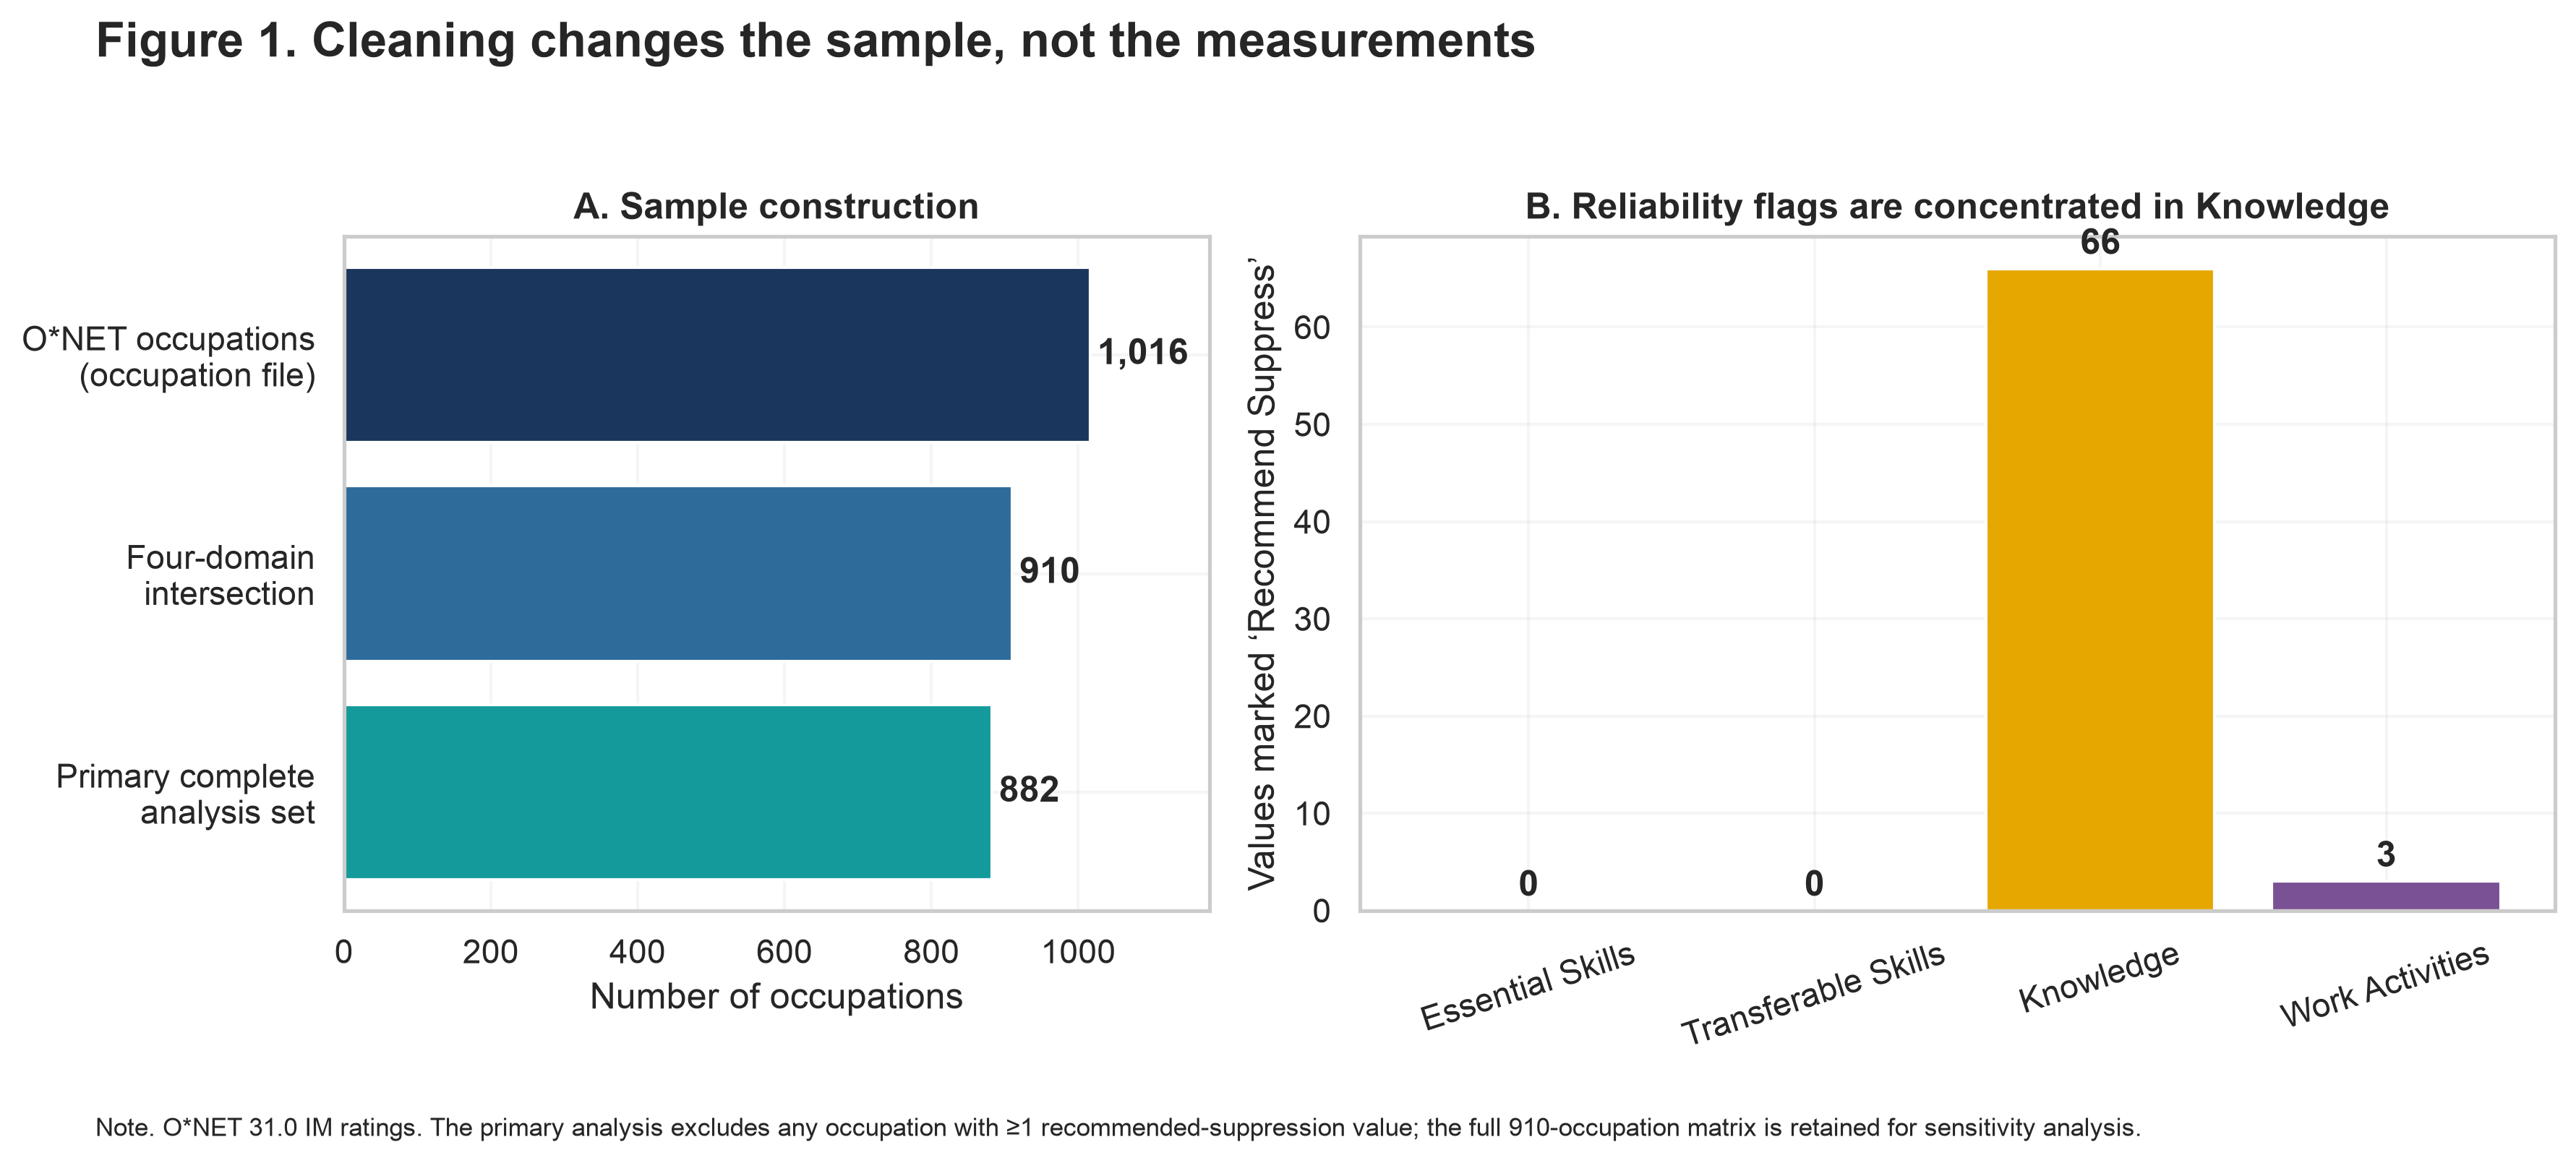

Cleaning sample flow and O*NET reliability flags by domain.


In [14]:
# FIGURE REVIEW: I display the saved high-resolution figure inside the executed notebook.
# The printed sentence below acts as a short text description of what the figure communicates.
display(Image(filename=str(FIGURES_DIR / 'figure_01_data_quality_and_sample_flow.png'), width=1050))
print('Cleaning sample flow and O*NET reliability flags by domain.')

### Figure 02 Pca Career Map

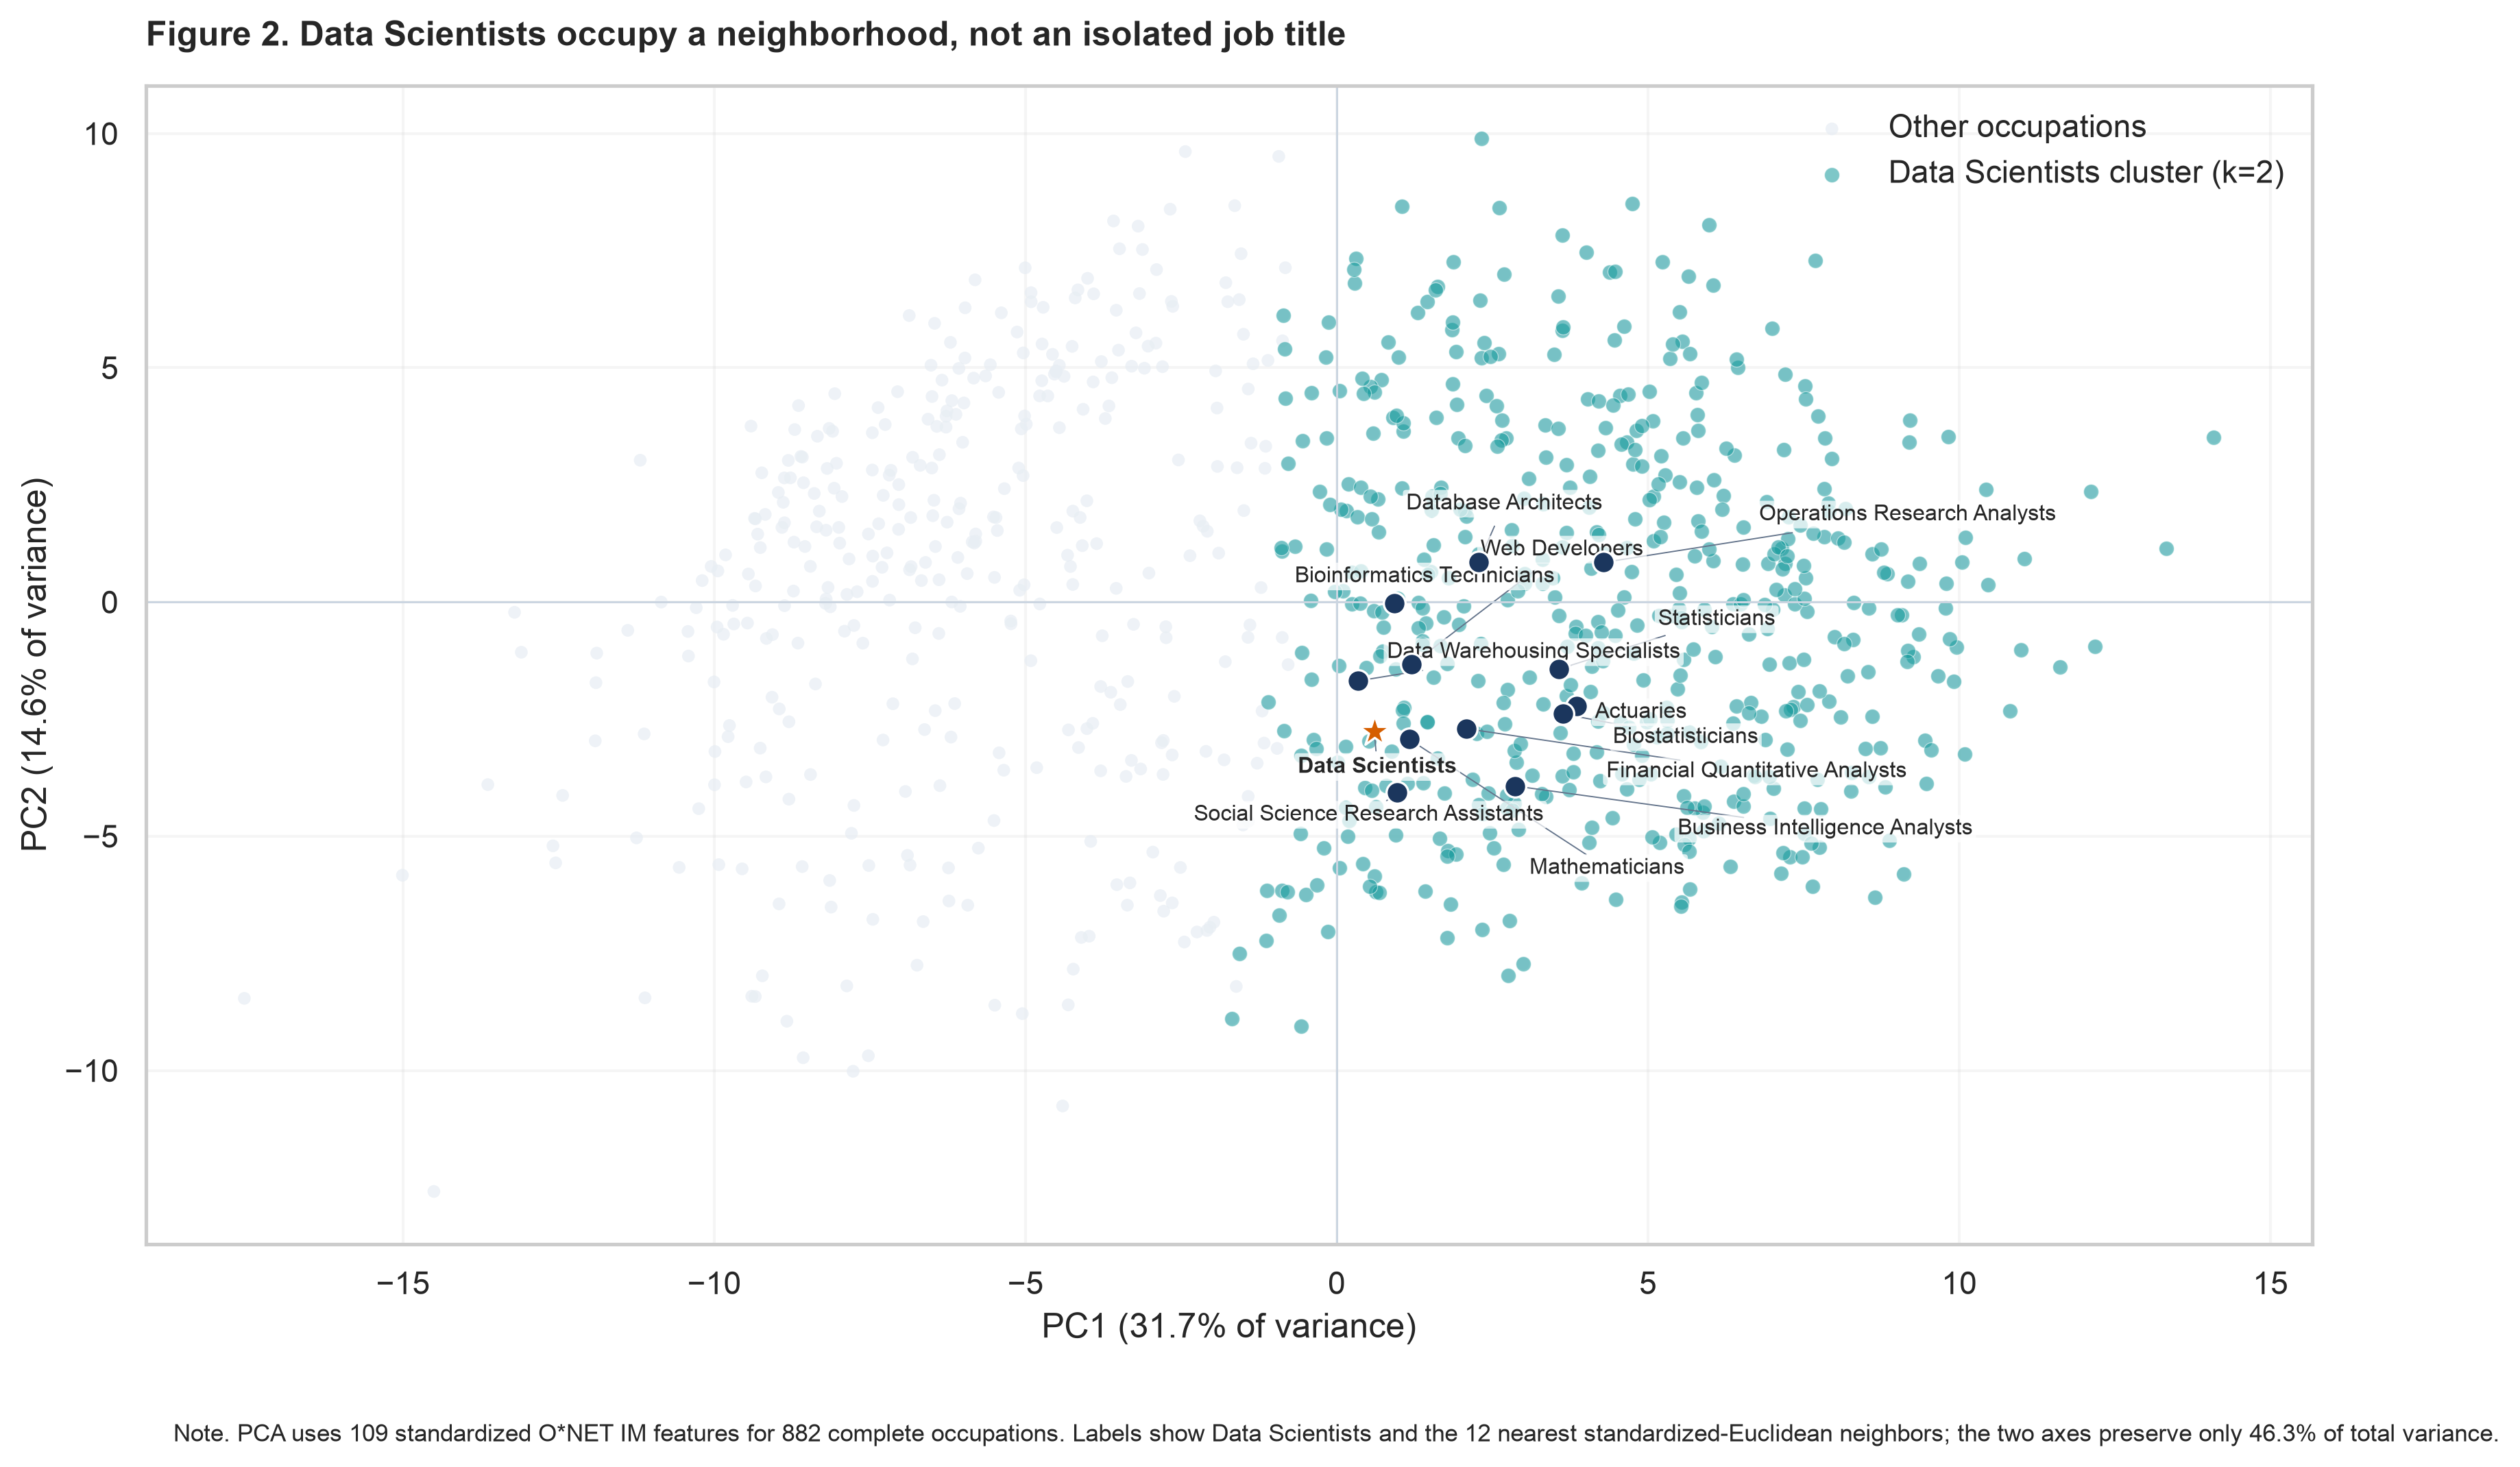

PCA map of 882 occupations with Data Scientists and nearest neighbors labeled.


In [15]:
# FIGURE REVIEW: I display the saved high-resolution figure inside the executed notebook.
# The printed sentence below acts as a short text description of what the figure communicates.
display(Image(filename=str(FIGURES_DIR / 'figure_02_pca_career_map.png'), width=1050))
print('PCA map of 882 occupations with Data Scientists and nearest neighbors labeled.')

### Figure 03 Nearest Occupations And Stability

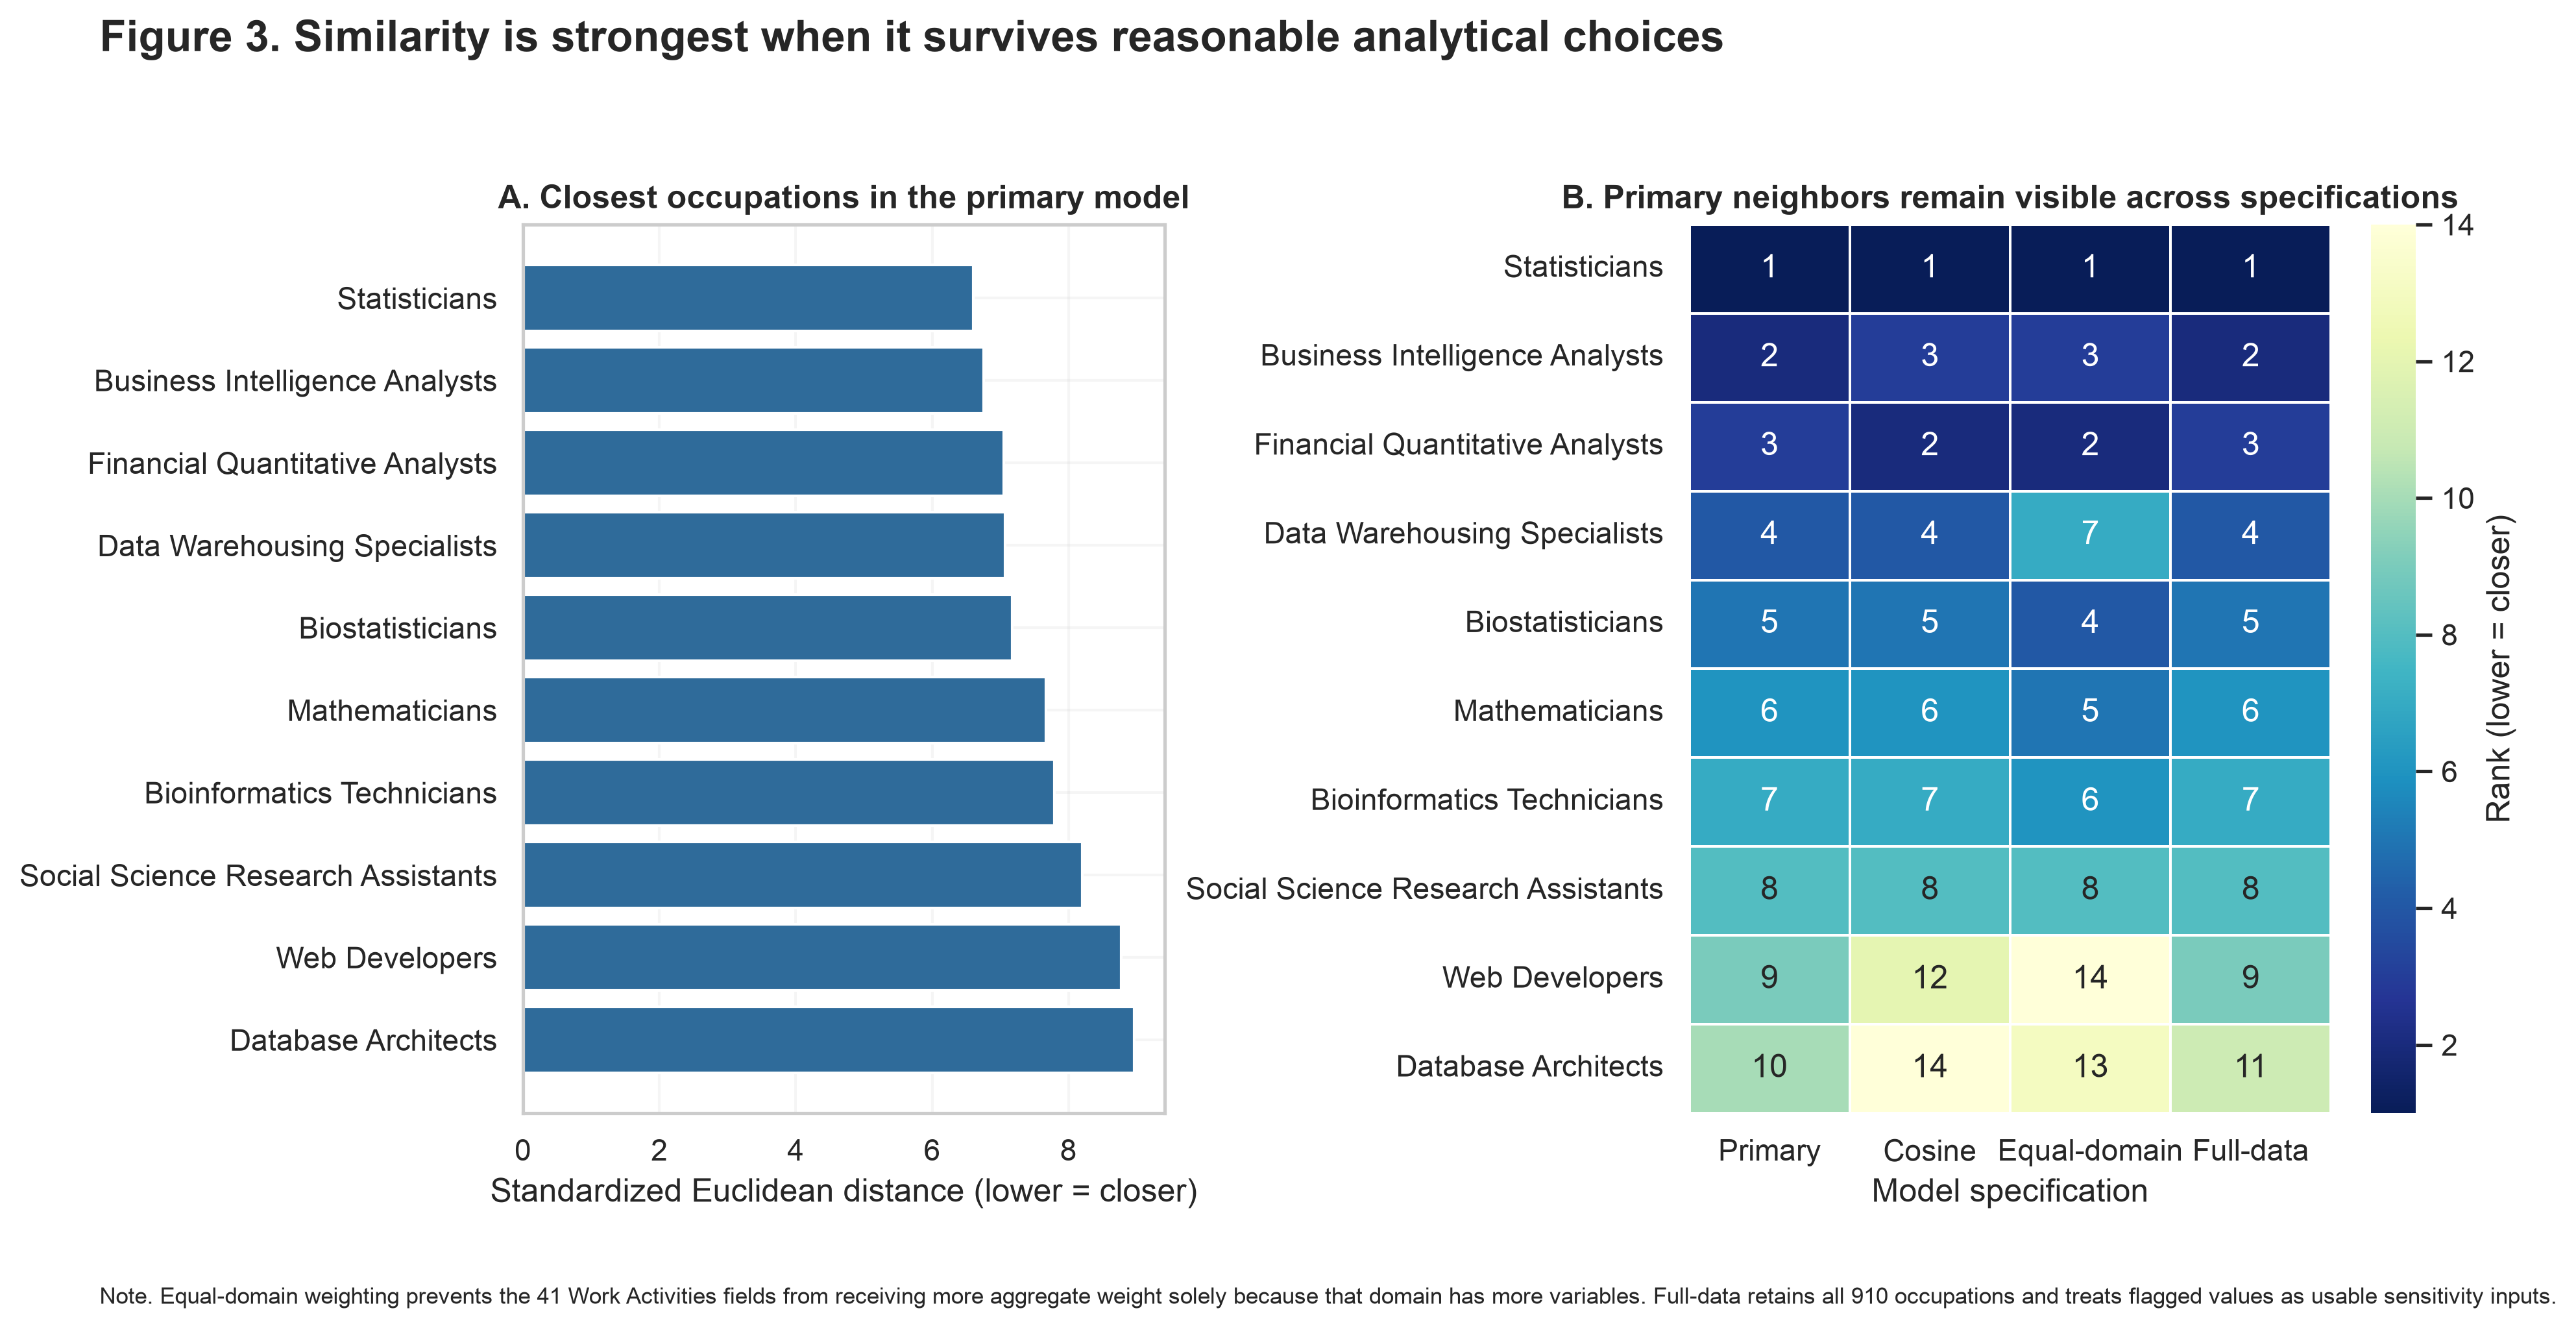

Nearest occupations and their ranks across sensitivity specifications.


In [16]:
# FIGURE REVIEW: I display the saved high-resolution figure inside the executed notebook.
# The printed sentence below acts as a short text description of what the figure communicates.
display(Image(filename=str(FIGURES_DIR / 'figure_03_nearest_occupations_and_stability.png'), width=1050))
print('Nearest occupations and their ranks across sensitivity specifications.')

### Figure 04 Cluster Validation And Profile

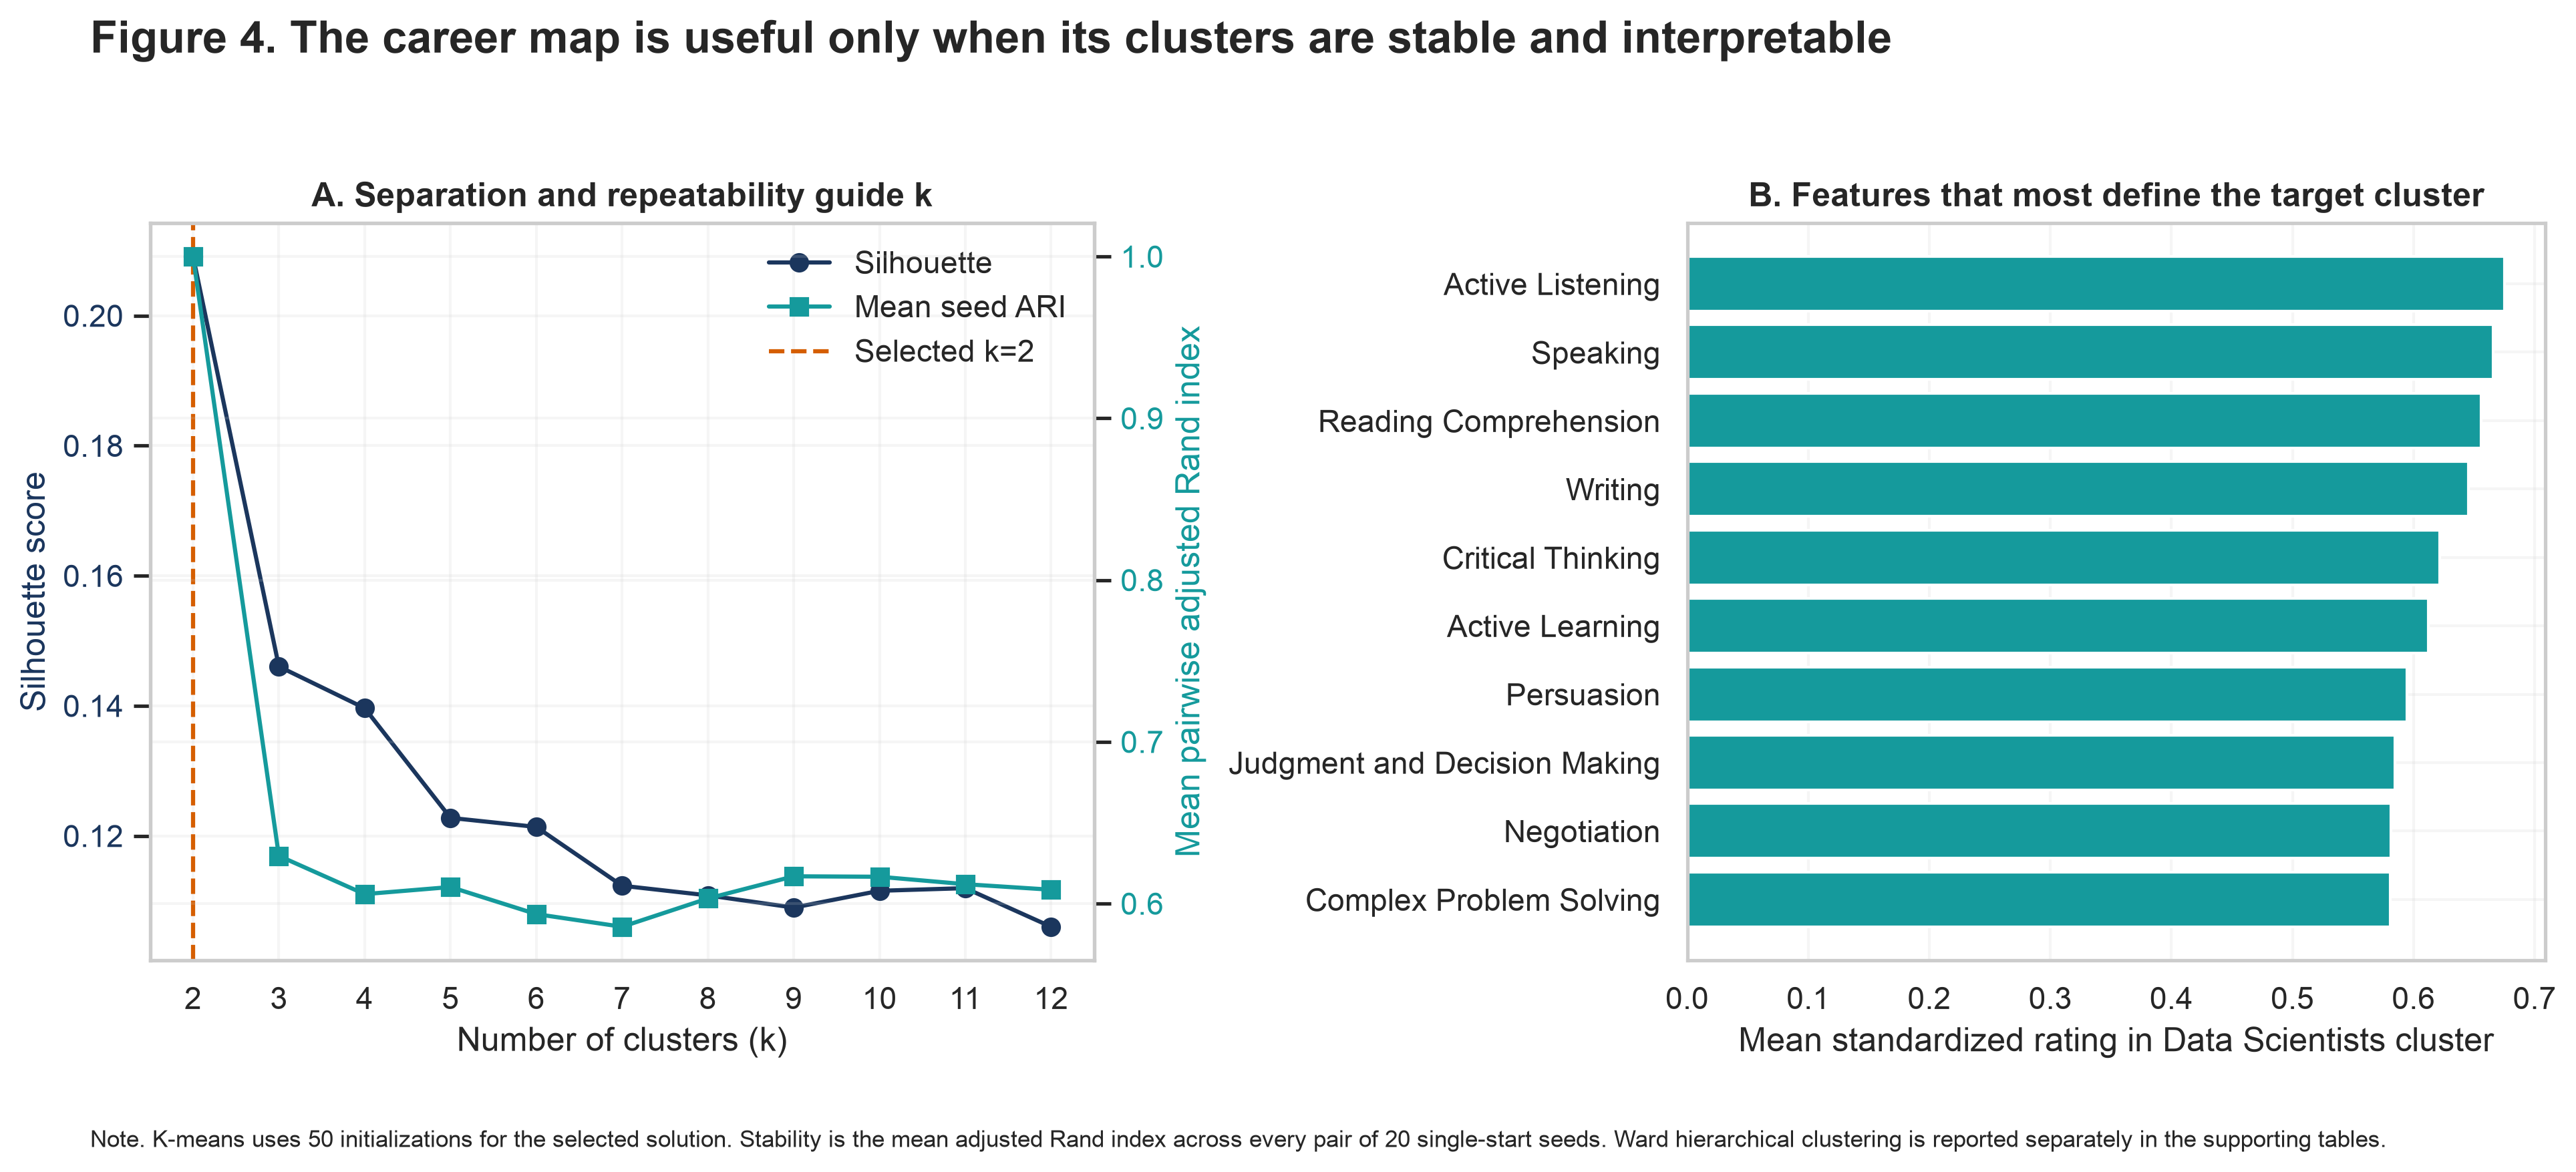

Cluster validation metrics and strongest features of the broad Data Scientists cluster.


In [17]:
# FIGURE REVIEW: I display the saved high-resolution figure inside the executed notebook.
# The printed sentence below acts as a short text description of what the figure communicates.
display(Image(filename=str(FIGURES_DIR / 'figure_04_cluster_validation_and_profile.png'), width=1050))
print('Cluster validation metrics and strongest features of the broad Data Scientists cluster.')

### Figure 05 Software Learning Roadmap

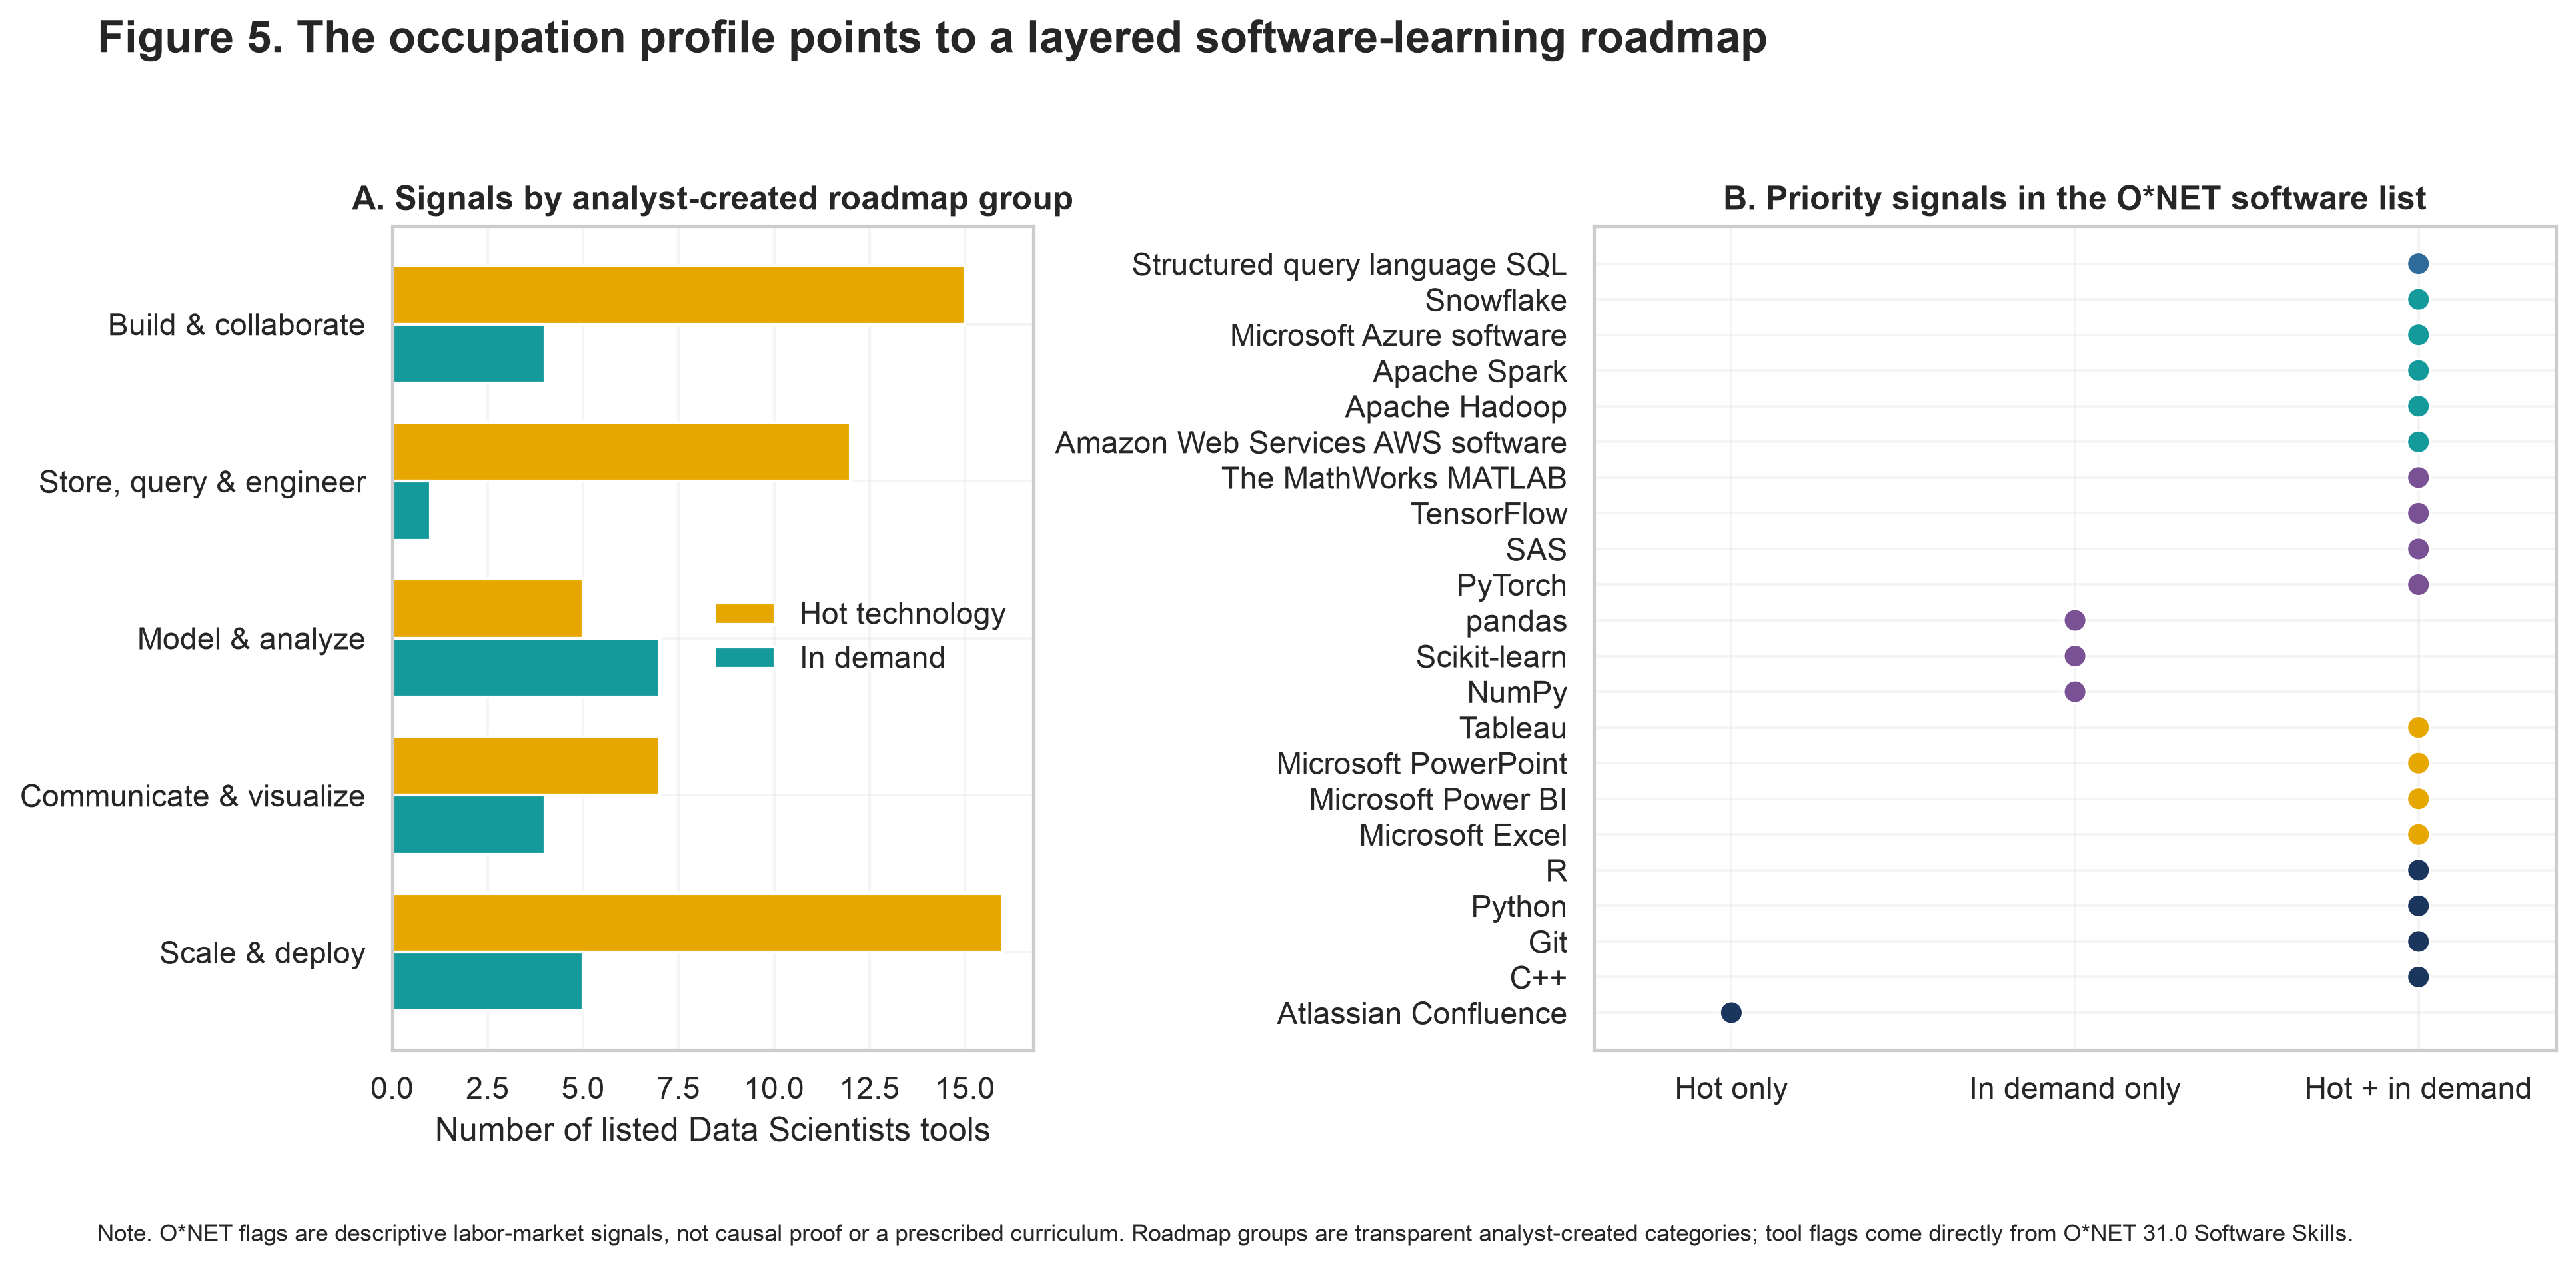

Hot and in-demand software signals grouped into a layered roadmap.


In [18]:
# FIGURE REVIEW: I display the saved high-resolution figure inside the executed notebook.
# The printed sentence below acts as a short text description of what the figure communicates.
display(Image(filename=str(FIGURES_DIR / 'figure_05_software_learning_roadmap.png'), width=1050))
print('Hot and in-demand software signals grouped into a layered roadmap.')

## Important note about my results

This project compares O*NET occupation profiles. It does not predict whether one person will be hired, measure salary, certify a training program, or prove that learning a specific tool will cause career success. I use the results to identify nearby occupations, understand which domains create the differences, and suggest questions for career advising and curriculum planning.
